# 🏠 PROYECTO FINAL - CIENCIA DE DATOS
## Análisis Predictivo del Mercado Inmobiliario

**Curso:** QR.LSTI2309TEO — Universidad Tecmilenio  
**Ponderación:** 35%  
**Temas:** Regresión Lineal Múltiple y Comunicación de Datos

---

## 📚 LIBRERÍAS Y CONFIGURACIÓN INICIAL

In [13]:
# ============================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Análisis estadístico
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Sistema de archivos
import os
from pathlib import Path

# Configuración
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Mostrar todas las columnas en pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# ============================================
# CONFIGURACIÓN DE CARPETAS PARA VISUALIZACIONES
# ============================================

# Nombre del archivo (sin extensión) para organizar visualizaciones
NOMBRE_PROYECTO = 'proyectoFinal'

# Crear estructura de carpetas
BASE_VIZ = Path('Visualizaciones')
CARPETA_VIZ = BASE_VIZ / NOMBRE_PROYECTO
CARPETA_VIZ.mkdir(parents=True, exist_ok=True)

def guardar_grafico(nombre_archivo, dpi=300):
    """Guarda el gráfico actual en la carpeta de visualizaciones"""
    ruta = CARPETA_VIZ / nombre_archivo
    plt.savefig(ruta, dpi=dpi, bbox_inches='tight')
    print(f"   💾 Guardado: {ruta}")

print("✅ Librerías importadas exitosamente")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"\n📁 Carpeta de visualizaciones: {CARPETA_VIZ}")

✅ Librerías importadas exitosamente
📊 Pandas version: 3.0.2
🔢 NumPy version: 2.4.4

📁 Carpeta de visualizaciones: Visualizaciones/proyectoFinal


---
# PARTE 1: MODELO DE REGRESIÓN LINEAL MÚLTIPLE
---

## 1️⃣ LIMPIEZA DE DATOS

**Objetivo:** Preparar los datos eliminando o imputando valores faltantes e identificando valores atípicos.

In [14]:
# ============================================
# 1.1 CARGA DE DATOS
# ============================================

print("="*70)
print("📂 CARGANDO DATOS")
print("="*70)

# Cargar dataset
df = pd.read_csv('Datos/train.csv')

print(f"\n✅ Datos cargados exitosamente")
print(f"   Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📂 CARGANDO DATOS

✅ Datos cargados exitosamente
   Dimensiones: 74111 filas × 29 columnas
   Memoria utilizada: 163.58 MB


In [15]:
# ============================================
# 1.2 EXPLORACIÓN INICIAL
# ============================================

print("="*70)
print("🔍 EXPLORACIÓN INICIAL DE DATOS")
print("="*70)

# Primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(df.head())

# Información general
print("\n📊 Información general del dataset:")
df.info()

🔍 EXPLORACIÓN INICIAL DE DATOS

📋 Primeras 5 filas del dataset:


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0



📊 Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity

In [16]:
# ============================================
# 1.3 ANÁLISIS DE TIPOS DE DATOS
# ============================================

print("="*70)
print("📊 ANÁLISIS DE TIPOS DE DATOS")
print("="*70)

# Crear DataFrame con información de columnas
info_columnas = pd.DataFrame({
    'Columna': df.columns,
    'Tipo': df.dtypes.values,
    'No_Nulos': df.count().values,
    'Nulos': df.isnull().sum().values,
    '%_Nulos': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Valores_Únicos': [df[col].nunique() for col in df.columns]
})

print("\n📋 Resumen de todas las columnas:")
display(info_columnas)

# Estadísticas por tipo
print("\n📊 Distribución de tipos de datos:")
print(df.dtypes.value_counts())

📊 ANÁLISIS DE TIPOS DE DATOS

📋 Resumen de todas las columnas:


,Columna,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Únicos
0,id,int64,74111,0,0.00,74111
1,log_price,float64,74111,0,0.00,767
2,property_type,str,74111,0,0.00,35
3,room_type,str,74111,0,0.00,3
4,amenities,str,74111,0,0.00,67122
5,accommodates,int64,74111,0,0.00,16
6,bathrooms,float64,73911,200,0.27,17
7,bed_type,str,74111,0,0.00,5
8,cancellation_policy,str,74111,0,0.00,5
9,cleaning_fee,bool,74111,0,0.00,2



📊 Distribución de tipos de datos:
str        18
float64     7
int64       3
bool        1
Name: count, dtype: int64


In [17]:
# ============================================
# 1.4 IDENTIFICACIÓN DE VARIABLES NUMÉRICAS
# ============================================

print("="*70)
print("🔢 VARIABLES NUMÉRICAS")
print("="*70)

# Identificar columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n✅ Total de variables numéricas: {len(columnas_numericas)}")
print("\n📋 Lista de variables numéricas:")
for i, col in enumerate(columnas_numericas, 1):
    print(f"   {i:2d}. {col:<30} (tipo: {df[col].dtype})")

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas de variables numéricas:")
display(df[columnas_numericas].describe().T)

🔢 VARIABLES NUMÉRICAS

✅ Total de variables numéricas: 10

📋 Lista de variables numéricas:
    1. id                             (tipo: int64)
    2. log_price                      (tipo: float64)
    3. accommodates                   (tipo: int64)
    4. bathrooms                      (tipo: float64)
    5. latitude                       (tipo: float64)
    6. longitude                      (tipo: float64)
    7. number_of_reviews              (tipo: int64)
    8. review_scores_rating           (tipo: float64)
    9. bedrooms                       (tipo: float64)
   10. beds                           (tipo: float64)

📊 Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
id,74111.0,1.126662e+07,6.081735e+06,344.000000,6.261964e+06,1.225415e+07,1.640226e+07,2.123090e+07
log_price,74111.0,4.782069e+00,7.173938e-01,0.000000,4.317488e+00,4.709530e+00,5.220356e+00,7.600402e+00
accommodates,74111.0,3.155146e+00,2.153589e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,73911.0,1.235263e+00,5.820441e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
latitude,74111.0,3.844596e+01,3.080167e+00,33.338905,3.412791e+01,4.066214e+01,4.074610e+01,4.239044e+01
longitude,74111.0,-9.239753e+01,2.170532e+01,-122.511500,-1.183424e+02,-7.699696e+01,-7.395466e+01,-7.098505e+01
number_of_reviews,74111.0,2.090057e+01,3.782864e+01,0.000000,1.000000e+00,6.000000e+00,2.300000e+01,6.050000e+02
review_scores_rating,57389.0,9.406736e+01,7.836556e+00,20.000000,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,74020.0,1.265793e+00,8.521435e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
beds,73980.0,1.710868e+00,1.254142e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.800000e+01


In [18]:
# ============================================
# 1.5 IDENTIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================

print("="*70)
print("📝 VARIABLES CATEGÓRICAS")
print("="*70)

# Identificar columnas categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n✅ Total de variables categóricas: {len(columnas_categoricas)}")
print("\n📋 Lista de variables categóricas:")
for i, col in enumerate(columnas_categoricas, 1):
    n_unique = df[col].nunique()
    print(f"   {i:2d}. {col:<30} ({n_unique} valores únicos)")

# Análisis detallado de cada variable categórica
print("\n📊 Análisis detallado de variables categóricas:")
for col in columnas_categoricas:
    print(f"\n{'='*70}")
    print(f"Variable: {col}")
    print(f"{'='*70}")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Valores nulos: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
    
    # Mostrar distribución si tiene pocos valores únicos
    if df[col].nunique() <= 20:
        print("\nDistribución de valores:")
        print(df[col].value_counts())
    else:
        print("\nTop 10 valores más frecuentes:")
        print(df[col].value_counts().head(10))

📝 VARIABLES CATEGÓRICAS

✅ Total de variables categóricas: 18

📋 Lista de variables categóricas:
    1. property_type                  (35 valores únicos)
    2. room_type                      (3 valores únicos)
    3. amenities                      (67122 valores únicos)
    4. bed_type                       (5 valores únicos)
    5. cancellation_policy            (5 valores únicos)
    6. city                           (6 valores únicos)
    7. description                    (73479 valores únicos)
    8. first_review                   (2554 valores únicos)
    9. host_has_profile_pic           (2 valores únicos)
   10. host_identity_verified         (2 valores únicos)
   11. host_response_rate             (80 valores únicos)
   12. host_since                     (3087 valores únicos)
   13. instant_bookable               (2 valores únicos)
   14. last_review                    (1371 valores únicos)
   15. name                           (73359 valores únicos)
   16. neighbourhood     

🔍 ANÁLISIS DE VALORES FALTANTES

⚠️  Columnas con valores faltantes: 13


,Columna,Valores_Faltantes,Porcentaje
15,host_response_rate,18299,24.69
24,review_scores_rating,16722,22.56
12,first_review,15864,21.41
18,last_review,15827,21.36
25,thumbnail_url,8216,11.09
22,neighbourhood,6872,9.27
26,zipcode,966,1.30
6,bathrooms,200,0.27
13,host_has_profile_pic,188,0.25
14,host_identity_verified,188,0.25


   💾 Guardado: Visualizaciones/proyectoFinal/01_valores_faltantes.png


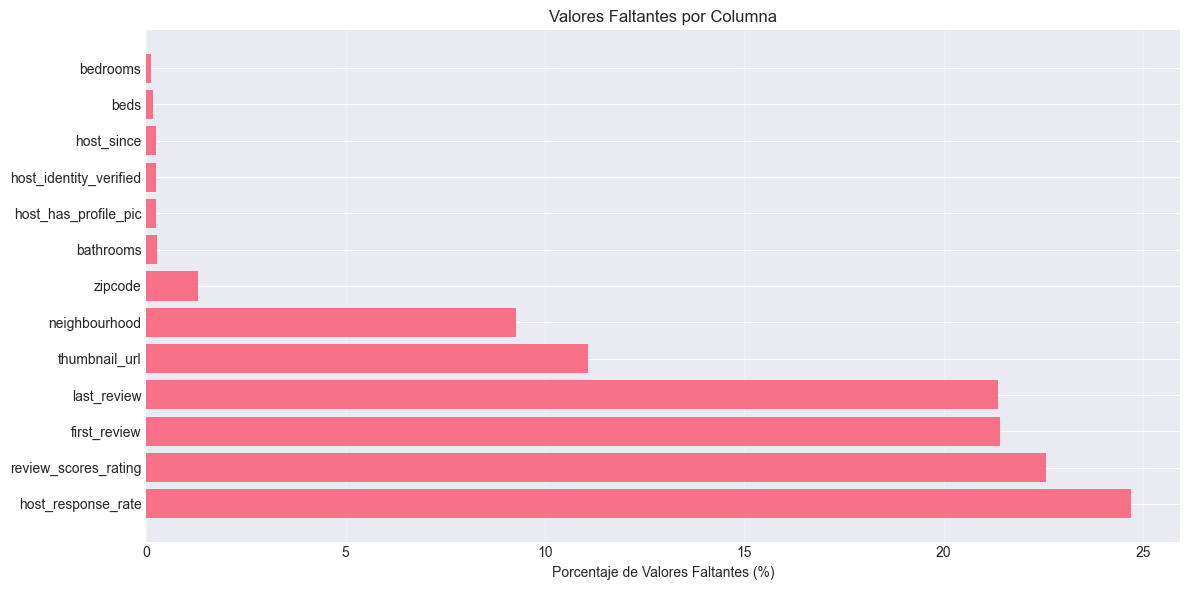

In [19]:
# ============================================
# 1.6 ANÁLISIS DE VALORES FALTANTES
# ============================================

print("="*70)
print("🔍 ANÁLISIS DE VALORES FALTANTES")
print("="*70)

# Calcular valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Valores_Faltantes': missing.values,
    'Porcentaje': missing_pct.values
})
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values(
    'Valores_Faltantes', ascending=False
)

if len(missing_df) > 0:
    print(f"\n⚠️  Columnas con valores faltantes: {len(missing_df)}")
    display(missing_df)
    
    # Visualización
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Columna'], missing_df['Porcentaje'])
    plt.xlabel('Porcentaje de Valores Faltantes (%)')
    plt.title('Valores Faltantes por Columna')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    guardar_grafico('01_valores_faltantes.png')
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

In [20]:
# ============================================
# 1.7 IMPUTACIÓN DE VALORES FALTANTES
# ============================================

print("="*70)
print("🔧 IMPUTACIÓN DE VALORES FALTANTES")
print("="*70)

# Crear copia para limpieza
df_limpio = df.copy()

# Imputar variables numéricas con la mediana
columnas_imputar_numericas = ['bathrooms', 'bedrooms', 'beds']
for col in columnas_imputar_numericas:
    if col in df_limpio.columns and df_limpio[col].isnull().sum() > 0:
        antes = df_limpio[col].isnull().sum()
        mediana = df_limpio[col].median()
        df_limpio[col].fillna(mediana, inplace=True)
        print(f"✅ {col}: {antes} valores imputados con mediana = {mediana:.2f}")

# Eliminar columnas con muchos valores faltantes o irrelevantes
print("\n🗑️  Eliminando columnas irrelevantes...")

columnas_eliminar = [
    'id', 'thumbnail_url', 'description', 'name',
    'first_review', 'last_review', 'host_since',
    'amenities', 'zipcode'
]

columnas_eliminar_existentes = [col for col in columnas_eliminar if col in df_limpio.columns]

if columnas_eliminar_existentes:
    print(f"\n📋 Columnas a eliminar ({len(columnas_eliminar_existentes)}):")
    for i, col in enumerate(columnas_eliminar_existentes, 1):
        tipo = df_limpio[col].dtype
        nulos = df_limpio[col].isnull().sum()
        pct_nulos = (nulos / len(df_limpio) * 100)
        print(f"   {i}. {col:<20} (tipo: {tipo}, nulos: {nulos} [{pct_nulos:.1f}%])")
    
    # Razones de eliminación
    print("\n💡 Razones de eliminación:")
    razones = {
        'id': 'Identificador único, no aporta información predictiva',
        'thumbnail_url': 'URL de imagen, no es numérica ni categórica útil',
        'description': 'Texto libre, requiere NLP (fuera del alcance)',
        'name': 'Texto libre, requiere NLP (fuera del alcance)',
        'first_review': 'Fecha, requiere feature engineering temporal',
        'last_review': 'Fecha, requiere feature engineering temporal',
        'host_since': 'Fecha, requiere feature engineering temporal',
        'amenities': 'Lista de texto, requiere procesamiento complejo',
        'zipcode': 'Código postal, alta cardinalidad y muchos nulos'
    }
    
    for col in columnas_eliminar_existentes:
        if col in razones:
            print(f"   • {col}: {razones[col]}")
    
    # Eliminar
    df_limpio = df_limpio.drop(columns=columnas_eliminar_existentes)
    print(f"\n✅ Eliminadas {len(columnas_eliminar_existentes)} columnas irrelevantes")
else:
    print("\n✅ No hay columnas para eliminar")

print(f"\n📊 Dimensiones después de limpieza: {df_limpio.shape}")

🔧 IMPUTACIÓN DE VALORES FALTANTES
✅ bathrooms: 200 valores imputados con mediana = 1.00
✅ bedrooms: 91 valores imputados con mediana = 1.00
✅ beds: 131 valores imputados con mediana = 1.00

🗑️  Eliminando columnas irrelevantes...

📋 Columnas a eliminar (9):
   1. id                   (tipo: int64, nulos: 0 [0.0%])
   2. thumbnail_url        (tipo: str, nulos: 8216 [11.1%])
   3. description          (tipo: str, nulos: 0 [0.0%])
   4. name                 (tipo: str, nulos: 0 [0.0%])
   5. first_review         (tipo: str, nulos: 15864 [21.4%])
   6. last_review          (tipo: str, nulos: 15827 [21.4%])
   7. host_since           (tipo: str, nulos: 188 [0.3%])
   8. amenities            (tipo: str, nulos: 0 [0.0%])
   9. zipcode              (tipo: str, nulos: 966 [1.3%])

💡 Razones de eliminación:
   • id: Identificador único, no aporta información predictiva
   • thumbnail_url: URL de imagen, no es numérica ni categórica útil
   • description: Texto libre, requiere NLP (fuera del alca

📊 DETECCIÓN DE OUTLIERS (MÉTODO IQR)

📊 Resumen de outliers:


,Variable,N_Outliers,Porcentaje,Límite_Inferior,Límite_Superior
0,log_price,1532,2.07%,2.96,6.57
1,accommodates,3604,4.86%,-1.00,7.00
2,bedrooms,24236,32.70%,1.00,1.00
3,beds,5686,7.67%,-0.50,3.50
4,bathrooms,15812,21.34%,1.00,1.00


   💾 Guardado: Visualizaciones/proyectoFinal/02_outliers_boxplots.png


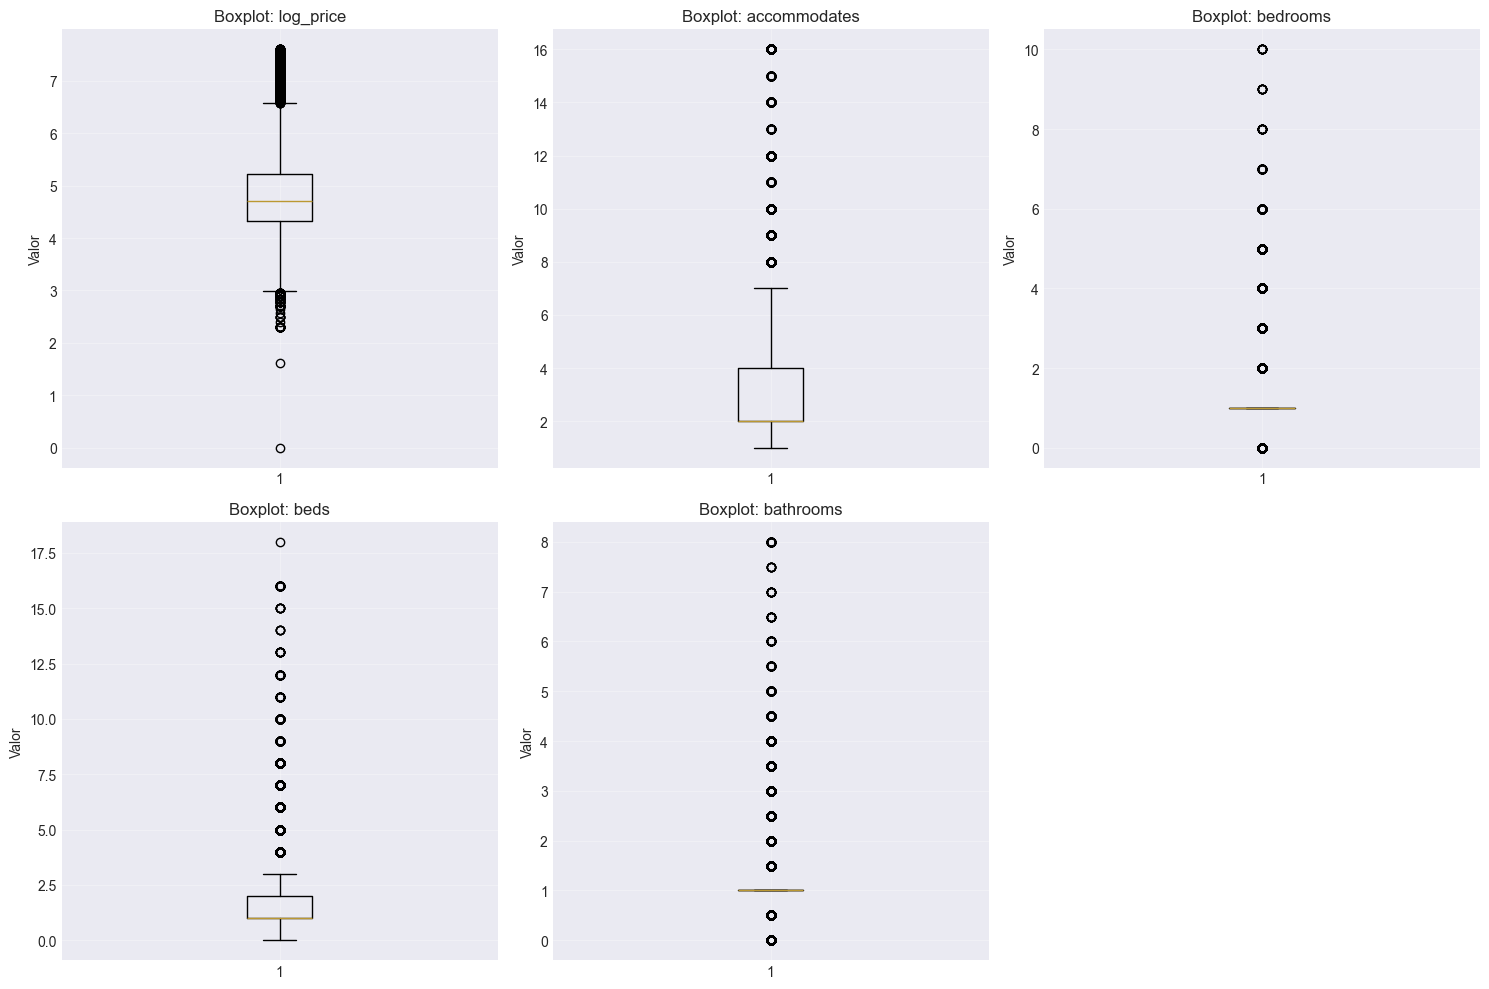


✅ Análisis de outliers completado
💡 Nota: Los outliers se mantienen por ahora para análisis posterior


In [21]:
# ============================================
# 1.8 DETECCIÓN DE OUTLIERS
# ============================================

print("="*70)
print("📊 DETECCIÓN DE OUTLIERS (MÉTODO IQR)")
print("="*70)

def detectar_outliers_iqr(data, columna, factor=1.5):
    """Detecta outliers usando el método IQR"""
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - factor * IQR
    limite_superior = Q3 + factor * IQR
    
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    
    return len(outliers), limite_inferior, limite_superior

# Analizar outliers en variables numéricas clave
variables_analizar = ['log_price', 'accommodates', 'bedrooms', 'beds', 'bathrooms']
variables_analizar = [col for col in variables_analizar if col in df_limpio.columns]

outliers_info = []
for col in variables_analizar:
    n_outliers, lim_inf, lim_sup = detectar_outliers_iqr(df_limpio, col)
    outliers_info.append({
        'Variable': col,
        'N_Outliers': n_outliers,
        'Porcentaje': f"{n_outliers/len(df_limpio)*100:.2f}%",
        'Límite_Inferior': f"{lim_inf:.2f}",
        'Límite_Superior': f"{lim_sup:.2f}"
    })

outliers_df = pd.DataFrame(outliers_info)
print("\n📊 Resumen de outliers:")
display(outliers_df)

# Visualización de boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(variables_analizar):
    if i < len(axes):
        axes[i].boxplot(df_limpio[col].dropna())
        axes[i].set_title(f'Boxplot: {col}')
        axes[i].set_ylabel('Valor')
        axes[i].grid(True, alpha=0.3)

# Ocultar ejes no utilizados
for i in range(len(variables_analizar), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
guardar_grafico('02_outliers_boxplots.png')
plt.show()

print("\n✅ Análisis de outliers completado")
print("💡 Nota: Los outliers se mantienen por ahora para análisis posterior")

In [22]:
# ============================================
# 1.9 RESUMEN DE LIMPIEZA
# ============================================

print("="*70)
print("📋 RESUMEN DE LIMPIEZA DE DATOS")
print("="*70)

print(f"\n📊 Dataset Original:")
print(f"   Filas: {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print(f"   Valores faltantes: {df.isnull().sum().sum():,}")

print(f"\n📊 Dataset Limpio:")
print(f"   Filas: {df_limpio.shape[0]:,}")
print(f"   Columnas: {df_limpio.shape[1]}")
print(f"   Valores faltantes: {df_limpio.isnull().sum().sum():,}")

print(f"\n✅ Limpieza completada exitosamente")

📋 RESUMEN DE LIMPIEZA DE DATOS

📊 Dataset Original:
   Filas: 74,111
   Columnas: 29
   Valores faltantes: 83,752

📊 Dataset Limpio:
   Filas: 74,111
   Columnas: 20
   Valores faltantes: 42,691

✅ Limpieza completada exitosamente


🔥 MAPA DE CALOR - CORRELACIÓN DE VARIABLES NUMÉRICAS

📊 Variables numéricas disponibles: 9

📋 Lista de variables numéricas:
    1. log_price
    2. accommodates
    3. bathrooms
    4. latitude
    5. longitude
    6. number_of_reviews
    7. review_scores_rating
    8. bedrooms
    9. beds
   💾 Guardado: Visualizaciones/proyectoFinal/03_mapa_calor_completo.png


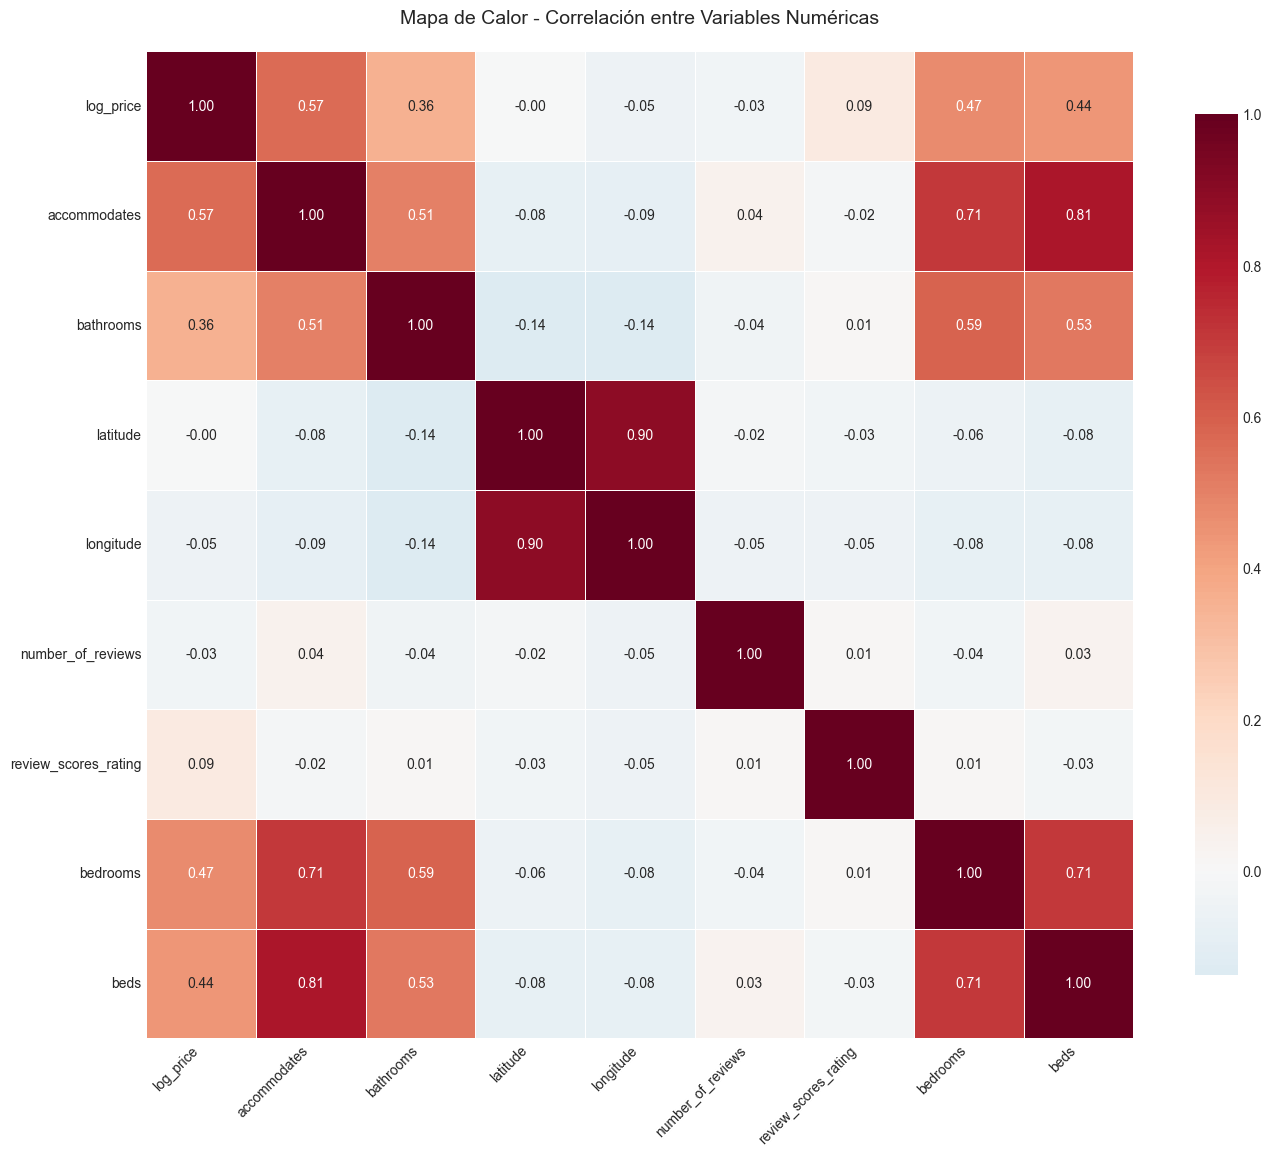


📊 Correlaciones con log_price (variable objetivo):

🔝 Top 10 correlaciones positivas:
    2. accommodates                    0.5676
    3. bedrooms                        0.4732
    4. beds                            0.4422
    5. bathrooms                       0.3554
    6. review_scores_rating            0.0912
    7. latitude                       -0.0022
    8. number_of_reviews              -0.0325
    9. longitude                      -0.0475

🔻 Top 5 correlaciones negativas:
    1. bathrooms                       0.3554
    2. review_scores_rating            0.0912
    3. latitude                       -0.0022
    4. number_of_reviews              -0.0325
    5. longitude                      -0.0475
   💾 Guardado: Visualizaciones/proyectoFinal/04_correlaciones_log_price.png


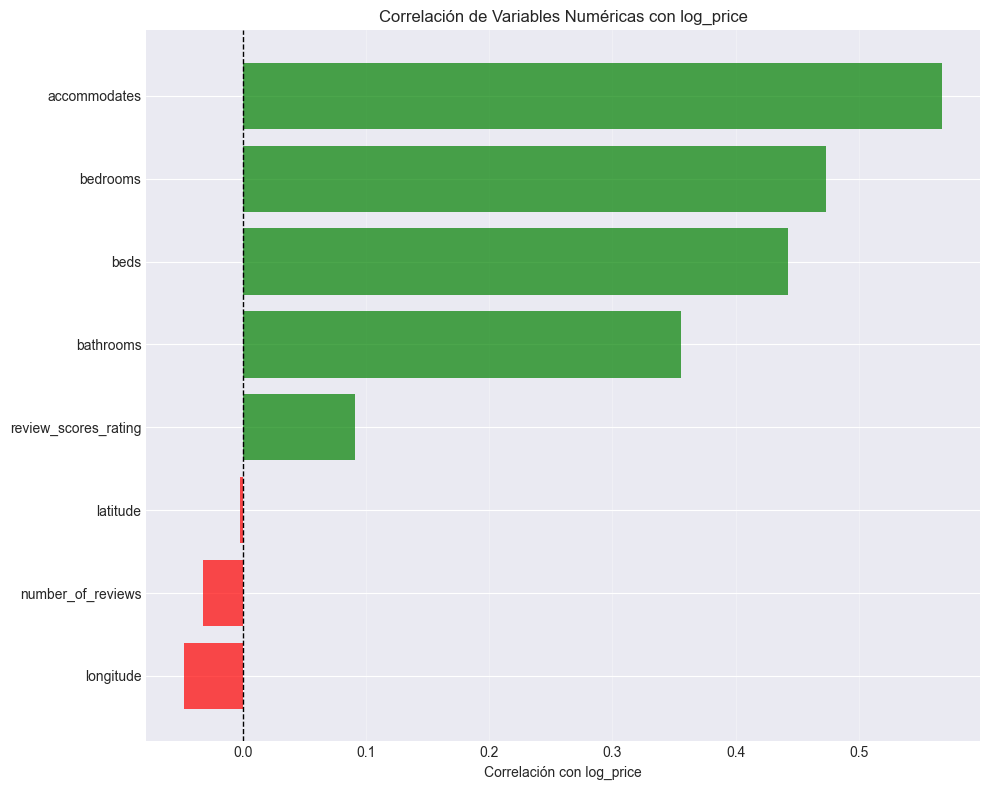


⚠️  Pares de variables con alta correlación (|r| > 0.8):
   1. accommodates ↔ beds: 0.8108
   2. latitude ↔ longitude: 0.8961

💡 Nota: Alta correlación entre variables puede indicar multicolinealidad

✅ Análisis de correlación completado


In [23]:
# ============================================
# 1.10 MAPA DE CALOR - TODAS LAS VARIABLES NUMÉRICAS
# ============================================

print("="*70)
print("🔥 MAPA DE CALOR - CORRELACIÓN DE VARIABLES NUMÉRICAS")
print("="*70)

# Seleccionar solo variables numéricas
df_numerico = df_limpio.select_dtypes(include=[np.number])

print(f"\n📊 Variables numéricas disponibles: {df_numerico.shape[1]}")
print("\n📋 Lista de variables numéricas:")
for i, col in enumerate(df_numerico.columns, 1):
    print(f"   {i:2d}. {col}")

# Calcular matriz de correlación
correlacion_matriz = df_numerico.corr()

# Crear mapa de calor
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlacion_matriz,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Mapa de Calor - Correlación entre Variables Numéricas', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
guardar_grafico('03_mapa_calor_completo.png')
plt.show()

# Análisis de correlaciones con log_price
if 'log_price' in df_numerico.columns:
    print("\n📊 Correlaciones con log_price (variable objetivo):")
    correlaciones_precio = correlacion_matriz['log_price'].sort_values(ascending=False)
    
    print("\n🔝 Top 10 correlaciones positivas:")
    for i, (var, corr) in enumerate(correlaciones_precio.head(11).items(), 1):
        if var != 'log_price':  # Excluir la correlación consigo misma
            print(f"   {i:2d}. {var:<30} {corr:>7.4f}")
    
    print("\n🔻 Top 5 correlaciones negativas:")
    for i, (var, corr) in enumerate(correlaciones_precio.tail(5).items(), 1):
        print(f"   {i:2d}. {var:<30} {corr:>7.4f}")
    
    # Visualización de correlaciones con log_price
    plt.figure(figsize=(10, 8))
    correlaciones_precio_sorted = correlaciones_precio.drop('log_price').sort_values()
    colors = ['red' if x < 0 else 'green' for x in correlaciones_precio_sorted]
    plt.barh(range(len(correlaciones_precio_sorted)), correlaciones_precio_sorted, color=colors, alpha=0.7)
    plt.yticks(range(len(correlaciones_precio_sorted)), correlaciones_precio_sorted.index)
    plt.xlabel('Correlación con log_price')
    plt.title('Correlación de Variables Numéricas con log_price')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    guardar_grafico('04_correlaciones_log_price.png')
    plt.show()

# Identificar pares de variables altamente correlacionadas
print("\n⚠️  Pares de variables con alta correlación (|r| > 0.8):")
alta_correlacion = []
for i in range(len(correlacion_matriz.columns)):
    for j in range(i+1, len(correlacion_matriz.columns)):
        if abs(correlacion_matriz.iloc[i, j]) > 0.8:
            var1 = correlacion_matriz.columns[i]
            var2 = correlacion_matriz.columns[j]
            corr = correlacion_matriz.iloc[i, j]
            alta_correlacion.append((var1, var2, corr))

if alta_correlacion:
    for i, (var1, var2, corr) in enumerate(alta_correlacion, 1):
        print(f"   {i}. {var1} ↔ {var2}: {corr:.4f}")
    print("\n💡 Nota: Alta correlación entre variables puede indicar multicolinealidad")
else:
    print("   ✅ No se encontraron pares con correlación > 0.8")

print("\n✅ Análisis de correlación completado")

## 2️⃣ IDENTIFICACIÓN DE VARIABLES

**Objetivo:** Definir la variable dependiente (target) y las variables independientes (features).

In [24]:
# ============================================
# 2.1 DEFINICIÓN DE VARIABLES
# ============================================

print("="*70)
print("🎯 IDENTIFICACIÓN DE VARIABLES")
print("="*70)

# Variable dependiente (target)
variable_dependiente = 'log_price'

print(f"\n🎯 VARIABLE DEPENDIENTE (Y):")
print(f"   {variable_dependiente}")
print(f"   Descripción: Logaritmo natural del precio de la propiedad")
print(f"   Tipo: {df_limpio[variable_dependiente].dtype}")
print(f"   Rango: [{df_limpio[variable_dependiente].min():.2f}, {df_limpio[variable_dependiente].max():.2f}]")
print(f"   Media: {df_limpio[variable_dependiente].mean():.2f}")
print(f"   Mediana: {df_limpio[variable_dependiente].median():.2f}")

# Variables independientes candidatas
print(f"\n📊 VARIABLES INDEPENDIENTES CANDIDATAS (X):")
print(f"\n🔢 Variables Numéricas:")
vars_numericas = df_limpio.select_dtypes(include=[np.number]).columns.tolist()
vars_numericas.remove(variable_dependiente)
for i, var in enumerate(vars_numericas, 1):
    print(f"   {i:2d}. {var}")

print(f"\n📝 Variables Categóricas:")
vars_categoricas = df_limpio.select_dtypes(include=['object']).columns.tolist()
for i, var in enumerate(vars_categoricas, 1):
    print(f"   {i:2d}. {var} ({df_limpio[var].nunique()} categorías)")

print(f"\n✅ Total de variables independientes: {len(vars_numericas) + len(vars_categoricas)}")

🎯 IDENTIFICACIÓN DE VARIABLES

🎯 VARIABLE DEPENDIENTE (Y):
   log_price
   Descripción: Logaritmo natural del precio de la propiedad
   Tipo: float64
   Rango: [0.00, 7.60]
   Media: 4.78
   Mediana: 4.71

📊 VARIABLES INDEPENDIENTES CANDIDATAS (X):

🔢 Variables Numéricas:
    1. accommodates
    2. bathrooms
    3. latitude
    4. longitude
    5. number_of_reviews
    6. review_scores_rating
    7. bedrooms
    8. beds

📝 Variables Categóricas:
    1. property_type (35 categorías)
    2. room_type (3 categorías)
    3. bed_type (5 categorías)
    4. cancellation_policy (5 categorías)
    5. city (6 categorías)
    6. host_has_profile_pic (2 categorías)
    7. host_identity_verified (2 categorías)
    8. host_response_rate (80 categorías)
    9. instant_bookable (2 categorías)
   10. neighbourhood (619 categorías)

✅ Total de variables independientes: 18


## 3️⃣ ANÁLISIS DE MULTICOLINEALIDAD (VIF)

**Objetivo:** Detectar multicolinealidad entre variables independientes usando el Factor de Inflación de la Varianza (VIF).

In [ ]:
# ============================================
# 3.1 CÁLCULO DEL VIF (VARIANCE INFLATION FACTOR)
# ============================================

print("="*70)
print("📊 ANÁLISIS DE MULTICOLINEALIDAD (VIF)")
print("="*70)

print("\n💡 ¿Qué es el VIF?")
print("   El Factor de Inflación de la Varianza (VIF) mide cuánto aumenta")
print("   la varianza de un coeficiente debido a la correlación con otras variables.")
print("\n📏 Interpretación:")
print("   • VIF = 1      : No hay correlación")
print("   • VIF < 5      : Multicolinealidad aceptable")
print("   • VIF 5-10     : Multicolinealidad moderada (considerar eliminar)")
print("   • VIF > 10     : Multicolinealidad alta (eliminar variable)")

# Seleccionar solo variables numéricas (excluyendo log_price)
vars_para_vif = [col for col in vars_numericas if col in df_limpio.columns]

if len(vars_para_vif) > 0:
    print(f"\n📊 Calculando VIF para {len(vars_para_vif)} variables numéricas...")
    
    # Preparar datos (eliminar nulos)
    df_vif = df_limpio[vars_para_vif].dropna()
    
    # Calcular VIF para cada variable
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) 
                       for i in range(len(df_vif.columns))]
    
    # Ordenar por VIF descendente
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
    
    # Agregar interpretación
    def interpretar_vif(vif):
        if vif < 5:
            return '✅ Aceptable'
        elif vif < 10:
            return '⚠️  Moderada'
        else:
            return '❌ Alta'
    
    vif_data['Interpretación'] = vif_data['VIF'].apply(interpretar_vif)
    
    # Mostrar resultados
    print("\n📋 Resultados del análisis VIF:")
    print("="*70)
    display(vif_data)
    
    # Resumen por categoría
    print("\n📊 Resumen:")
    aceptable = len(vif_data[vif_data['VIF'] < 5])
    moderada = len(vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)])
    alta = len(vif_data[vif_data['VIF'] >= 10])
    
    print(f"   ✅ Multicolinealidad aceptable (VIF < 5):    {aceptable} variables")
    print(f"   ⚠️  Multicolinealidad moderada (VIF 5-10):   {moderada} variables")
    print(f"   ❌ Multicolinealidad alta (VIF > 10):        {alta} variables")
    
    # Identificar variables problemáticas
    if alta > 0:
        print("\n⚠️  ADVERTENCIA: Variables con multicolinealidad alta:")
        vars_problematicas = vif_data[vif_data['VIF'] >= 10]
        for idx, row in vars_problematicas.iterrows():
            print(f"   • {row['Variable']}: VIF = {row['VIF']:.2f}")
        print("\n💡 Recomendación: Considerar eliminar estas variables del modelo")
    elif moderada > 0:
        print("\n⚠️  Variables con multicolinealidad moderada:")
        vars_moderadas = vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] < 10)]
        for idx, row in vars_moderadas.iterrows():
            print(f"   • {row['Variable']}: VIF = {row['VIF']:.2f}")
        print("\n💡 Recomendación: Monitorear estas variables durante el modelado")
    else:
        print("\n✅ ¡Excelente! No hay problemas de multicolinealidad")
    
    # Visualización del VIF
    plt.figure(figsize=(12, 8))
    
    # Colores según nivel de VIF
    colors = ['green' if x < 5 else 'orange' if x < 10 else 'red' for x in vif_data['VIF']]
    
    plt.barh(vif_data['Variable'], vif_data['VIF'], color=colors, alpha=0.7)
    plt.xlabel('VIF (Factor de Inflación de la Varianza)', fontsize=12)
    plt.ylabel('Variables', fontsize=12)
    plt.title('Análisis de Multicolinealidad - VIF por Variable', fontsize=14, pad=20)
    
    # Líneas de referencia
    plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='VIF = 5 (Moderado)')
    plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10 (Alto)')
    
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    guardar_grafico('05_analisis_vif.png')
    plt.show()
    
    # Análisis de pares correlacionados
    print("\n📊 Análisis de pares de variables altamente correlacionadas:")
    print("="*70)
    
    # Calcular correlaciones
    corr_matrix = df_vif.corr()
    
    # Encontrar pares con alta correlación
    pares_alta_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                var1 = corr_matrix.columns[i]
                var2 = corr_matrix.columns[j]
                corr = corr_matrix.iloc[i, j]
                pares_alta_corr.append({
                    'Variable 1': var1,
                    'Variable 2': var2,
                    'Correlación': corr,
                    'Abs': abs(corr)
                })
    
    if pares_alta_corr:
        df_pares = pd.DataFrame(pares_alta_corr).sort_values('Abs', ascending=False)
        df_pares = df_pares.drop('Abs', axis=1)
        
        print(f"\n⚠️  Encontrados {len(df_pares)} pares con |correlación| > 0.7:")
        display(df_pares)
        
        print("\n💡 Interpretación:")
        print("   Estos pares de variables están altamente correlacionados.")
        print("   Considerar mantener solo una de cada par en el modelo final.")
    else:
        print("\n✅ No se encontraron pares con correlación > 0.7")
    
    print("\n✅ Análisis de multicolinealidad completado")
    
else:
    print("\n⚠️  No hay suficientes variables numéricas para calcular VIF")

---
**📝 CHECKPOINT 1 COMPLETADO**

✅ Limpieza de datos realizada  
✅ Variables identificadas  
✅ Tipos de datos analizados  
✅ Valores faltantes tratados  
✅ Outliers detectados  
✅ Multicolinealidad analizada (VIF)

**Próximos pasos:**
- Selección de características
- Análisis de correlación
- Construcción del modelo

---